# Telecom Customer Churn Analysis

## 1. Project Overview

This project analyzes customer churn for a telecommunications company using the IBM Telco Customer Churn dataset.

**Objectives:**
- Clean and explore the dataset
- Identify key factors that drive customer churn
- Perform statistical hypothesis testing
- Provide actionable business insights and recommendations

**Skills demonstrated:**  
Pandas, NumPy, Matplotlib, Seaborn, Descriptive & Inferential Statistics, Hypothesis Testing

In [34]:
#import all libraries we need
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%matplotlib inline
sns.set_style('whitegrid')

print('All Libraries imported successfully!')

All Libraries imported successfully!


## 2. Data Loading & Cleaning

In [35]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
tel_data = pd.read_csv(url)
print('Original Shape:\n', tel_data.shape)

#check data types and missing values
tel_dtype = tel_data.dtypes
tel_nan = tel_data.isnull().sum()
print('\nData Type for each column:\n', tel_dtype)
print('\nColumns with Missing values:\n', tel_nan)

#convert totalcharges from string to numeric
tel_tc = pd.to_numeric(tel_data['TotalCharges'], errors='coerce')
print('\nTotalCharges converted from str to num:\n', tel_tc)

#assign converted values to dataframes column
tel_data['TotalCharges'] = tel_tc

#Check if TotalCharges is updated 
tc = tel_data['TotalCharges'].dtypes
print('\nUpdated data types for TotalCharges:\n', tc)

tel_data = tel_data.dropna(subset=['TotalCharges'])
print("Shape after drop:", tel_data.shape)
print("Missing TotalCharges:", tel_data['TotalCharges'].isnull().sum())

Original Shape:
 (7043, 21)

Data Type for each column:
 customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Columns with Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
St

## 3. Exploratory Data Analysis
### 3.1 Overall Churn Rate

In [36]:

#initialize counter variable churn_rate and convert 'churn' column into a boolean series.
churn_rate = (tel_data['Churn'] == 'Yes').mean() * 100
print('Churn rate: {:.2f}%'.format(churn_rate))

Churn rate: 26.58%


### 3.2 Numeric features by Churn group

In [37]:
#Transform tel_data into a dataframe 
tel_df = pd.DataFrame(tel_data)

#Split the dataframes into two groups Churners vs Non-churners
churners = tel_df.loc[tel_df['Churn'] == 'Yes']
non_churners = tel_df.loc[tel_df['Churn'] == 'No']

#calulates Descriptive stats for Churners and Non-churners group
info_c = churners[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()
info_nc = non_churners[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()
print('\nChurners:\n', info_c)
print('\nNon-Churners:\n', info_nc)


Churners:
             tenure  MonthlyCharges  TotalCharges
count  1869.000000     1869.000000   1869.000000
mean     17.979133       74.441332   1531.796094
std      19.531123       24.666053   1890.822994
min       1.000000       18.850000     18.850000
25%       2.000000       56.150000    134.500000
50%      10.000000       79.650000    703.550000
75%      29.000000       94.200000   2331.300000
max      72.000000      118.350000   8684.800000

Non-Churners:
            tenure  MonthlyCharges  TotalCharges
count  5163.00000     5163.000000   5163.000000
mean     37.65001       61.307408   2555.344141
std      24.07694       31.094557   2329.456984
min       1.00000       18.250000     18.800000
25%      15.00000       25.100000    577.825000
50%      38.00000       64.450000   1683.600000
75%      61.00000       88.475000   4264.125000
max      72.00000      118.750000   8672.450000


### 3.3 Visualizations – Boxplots

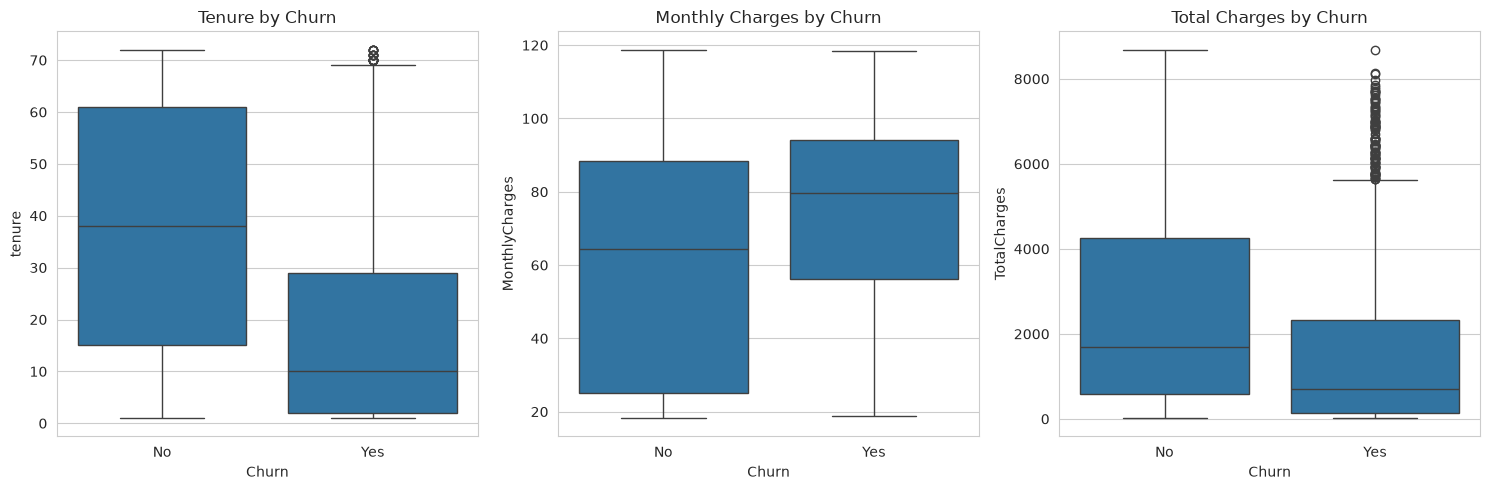

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(x='Churn', y='tenure', data=tel_data, ax=axes[0])
axes[0].set_title('Tenure by Churn')

sns.boxplot(x='Churn', y='MonthlyCharges', data=tel_data, ax=axes[1])
axes[1].set_title('Monthly Charges by Churn')

sns.boxplot(x='Churn', y='TotalCharges', data=tel_data, ax=axes[2])
axes[2].set_title('Total Charges by Churn')

plt.tight_layout()

#save the image
plt.savefig('../results/boxplot_numeric_features.png', dpi=300, bbox_inches='tight')
plt.show()


## 4. Statistical Hypothesis Testing 

In [39]:
import sys
sys.path.append('..')
from src.utils import churn_rate_by, run_ttest

# Run tests
run_ttest('MonthlyCharges', churners, non_churners, 'Monthly Charges')
run_ttest('TotalCharges', churners, non_churners, 'Total Charges')
run_ttest('tenure', churners, non_churners, 'Tenure')


Monthly Charges
t-statistic: 18.3409
p-value: 2.6574e-72
→ Reject H0: There is a significant difference in mean Monthly Charges.

Total Charges
t-statistic: -18.8008
p-value: 1.1525e-75
→ Reject H0: There is a significant difference in mean Total Charges.

Tenure
t-statistic: -34.9719
p-value: 2.3471e-234
→ Reject H0: There is a significant difference in mean Tenure.


(np.float64(-34.97187009750348), np.float64(2.34707471889502e-234))

## 5. Key Business Insight and Risk Factors.
### 5.1 Summary of Key Findings

- **Overall Churn Rate**: 26.58%

- **Average Tenure**  
  - Churners: **18 months**  
  - Non-churners: **38 months**

- **Average Monthly Charges**  
  - Churners: **$74**  
  - Non-churners: **$61**

- **Average Total Charges**  
  - Churners: **$1,531**  
  - Non-churners: **$2,555**

- **Hypothesis Testing**  
  All three features (MonthlyCharges, TotalCharges, and Tenure) show **statistically significant differences** between churners and non-churners (p-values ≪ 0.05).

In [40]:
#churn_rate_by function to caluclate risks associated with Contract, InternetService, and PaymentMethod
print("Contract type vs Churn:")
print(churn_rate_by(tel_data, 'Contract'))

print("\nInternet Service vs Churn:")
print(churn_rate_by(tel_data, 'InternetService'))

print("\nPayment Method vs Churn:")
print(churn_rate_by(tel_data, 'PaymentMethod'))

Contract type vs Churn:
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.72  11.28
Two year        97.15   2.85

Internet Service vs Churn:
Churn               No    Yes
InternetService              
DSL              81.00  19.00
Fiber optic      58.11  41.89
No               92.57   7.43

Payment Method vs Churn:
Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.27  16.73
Credit card (automatic)    84.75  15.25
Electronic check           54.71  45.29
Mailed check               80.80  19.20


### 5.2 Risk Factors

- Overall customer churn rate is **26.58%**.

- **Tenure** is the strongest continuous predictor:  
  Churners stay only **18 months** on average versus **38 months** for non-churners.

- Churners pay higher monthly charges (**$74** vs **$61**) but lower total charges because they leave early.

- **Contract type** is the strongest categorical risk factor:  
  - Month-to-month → **42.7%** churn  
  - One-year → **11.3%** churn  
  - Two-year → **2.9%** churn  

- **Internet Service**: Fiber optic customers churn at **41.9%**, much higher than DSL (19%) or no internet (7.4%).

- **Payment Method**: Electronic check customers have the highest churn rate at **45.3%**.

**High-Risk Profile**  
Customers who combine **Month-to-month contract + Fiber optic + Electronic check** represent a particularly high-risk segment and should be prioritized for retention offers.

## 6. Recommendations

Based on the analysis, the following actions are recommended:

1. **Focus retention efforts on Month-to-month customers**  
   This group has a 42.7% churn rate. Offer incentives to switch to 1-year or 2-year contracts.

2. **Investigate Fiber Optic service quality and pricing**  
   Fiber optic customers churn at 41.9%. Review pricing, service reliability, and competitor offers.

3. **Reduce reliance on Electronic Check payments**  
   Customers using Electronic Check have the highest churn rate (45.3%). Encourage automatic payment methods (bank transfer or credit card).

4. **Target early-tenure customers**  
   Customers in their first 12–18 months are at highest risk. Implement onboarding and early engagement programs.

5. **Create a high-risk customer score**  
   Flag customers who combine Month-to-month + Fiber optic + Electronic check for proactive retention offers.

## 7. Conclusion

This analysis identified several clear drivers of customer churn in the telecom dataset. Tenure, contract type, internet service, and payment method are the most important factors.

By focusing retention efforts on high-risk segments — especially month-to-month customers with fiber optic service who pay by electronic check — the company has a strong opportunity to reduce overall churn from the current 26.6% rate.

The combination of exploratory analysis, statistical testing, and clear business insights demonstrates a practical data-driven approach to solving a real business problem.

In [41]:
# Save the cleaned dataset
tel_data.to_csv('../data/telco_churn_cleaned.csv', index=False)
print("Cleaned data saved successfully!")

Cleaned data saved successfully!
